In [83]:
import numpy as np
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.optimize import minimize
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import pyomo.environ as pyo
from pyomo.environ import SolverFactory
from pyomo.environ import *
import random



In [82]:
## 1. Gerar Grid
linha = 10

grid = np.zeros((linha,linha,linha))

# for i in range(linha):
#     for j in range(linha):
#         for k in range(linha):
            




print(grid)

[[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]

 [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]

 [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0

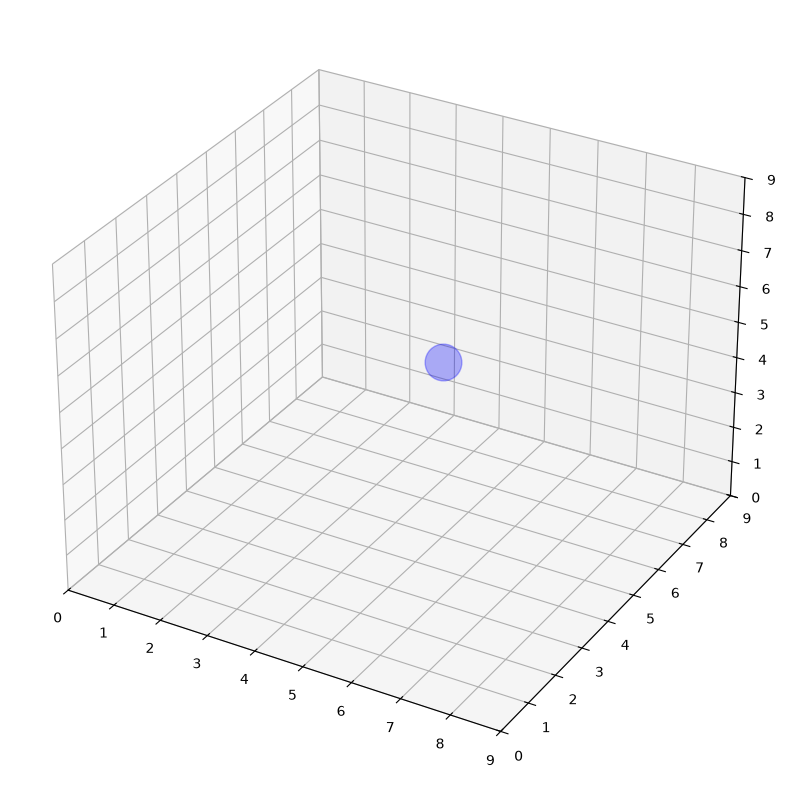

In [108]:
# Initialize 3D axes
fig = plt.figure(figsize=(linha,linha))
ax = fig.add_subplot(projection='3d')


ax.scatter(5,5,5, marker='o',s=700,alpha=0.55,color='blue')

ax.set_xbound(0,linha-1)            
ax.set_ybound(0,linha-1)            
ax.set_zbound(0,linha-1)  

In [ ]:


class MyProblem(ElementwiseProblem):

    def __init__(self):
        super().__init__(n_var=len(dict_peso_relacao),
                         n_obj=2,
                         
                         xl=np.array([-5,-5]),
                         xu=np.array([5,5]))

    def _evaluate(self, X, out, *args, **kwargs):

        x = X[0]
        y = X[1]
        
        f1 = x**2 + y**2
        f2 = (x-1)**2 + (y-1)**2
        out["F"] = [f1,f2]
       


problem = MyProblem()

algorithm = NSGA2(
    n_max_gen = 100,
    pop_size=40,
    n_offsprings=10,
    eliminate_duplicates=True,
    save_history=True
)

In [ ]:
res = minimize(problem,
               algorithm,
               
               seed=1,
               save_history=True,
               verbose=True)

X = res.X
F = res.F

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       40 |      5 |             - |             -
     2 |       50 |      5 |  0.000000E+00 |             f
     3 |       60 |      2 |  2.5150979288 |         ideal
     4 |       70 |      3 |  0.0420536646 |         ideal
     5 |       80 |      3 |  0.000000E+00 |             f
     6 |       90 |      4 |  0.0639861390 |         ideal
     7 |      100 |      5 |  0.0179375914 |             f
     8 |      110 |      7 |  0.0486860695 |         ideal
     9 |      120 |      7 |  0.0364733594 |         ideal
    10 |      130 |      8 |  0.0633876026 |             f
    11 |      140 |     10 |  0.0104388069 |         nadir
    12 |      150 |     13 |  0.0102943964 |             f
    13 |      160 |     13 |  0.000000E+00 |             f
    14 |      170 |     14 |  0.0089569427 |             f
    15 |      180 |     15 |  0.0102187983 |         ideal
    16 |      190 |     18 |  0.0030042490 |         nad